Task 1

In [1]:
from torchvision import datasets

dataset = datasets.ImageFolder(r"C:\Users\alias\Downloads\Five_Faces")

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 694
Classes: ['gates', 'jack', 'modi', 'musk', 'trump']


In [2]:
from collections import Counter

labels = [label for _, label in dataset]
counts = Counter(labels)

print("Number of identities:", len(counts))

for i, count in counts.items():
    print(f"{dataset.classes[i]}: {count} images")

Number of identities: 5
gates: 137 images
jack: 134 images
modi: 142 images
musk: 137 images
trump: 144 images


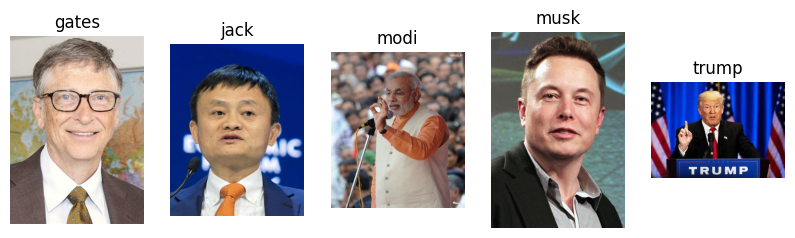

In [3]:
import matplotlib.pyplot as plt

shown = set()

plt.figure(figsize=(10,5))

for img, label in dataset:
    if label not in shown:
        plt.subplot(1, 5, len(shown)+1)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis("off")
        shown.add(label)
    
    if len(shown) == 5:
        break

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

Train size: 555
Test size: 139


In [5]:
train_labels = [labels[i] for i in train_idx]
test_labels = [labels[i] for i in test_idx]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({4: 115, 2: 113, 0: 110, 3: 110, 1: 107})
Test distribution: Counter({2: 29, 4: 29, 1: 27, 0: 27, 3: 27})


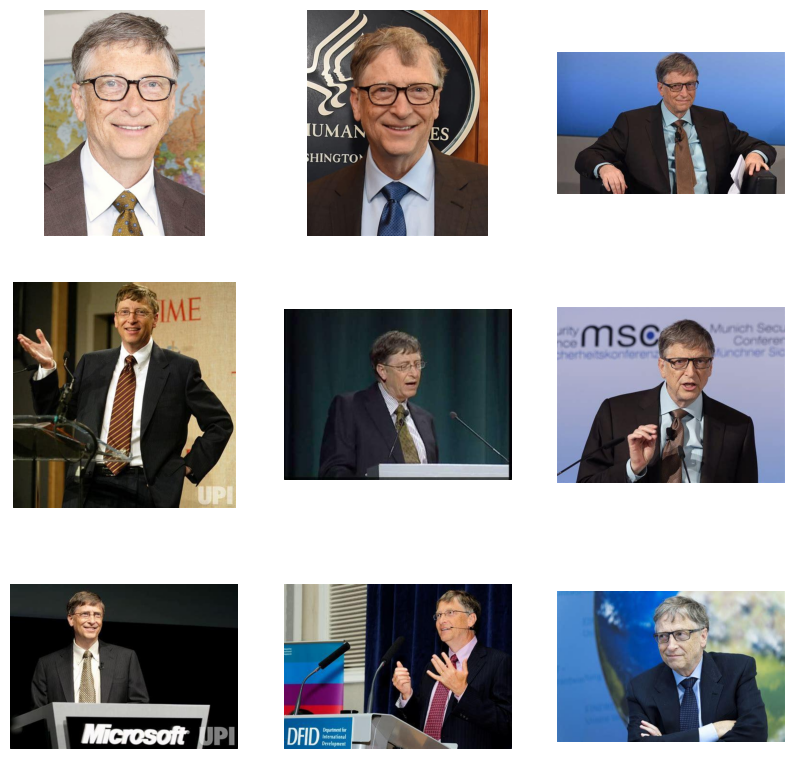

In [6]:
plt.figure(figsize=(10,10))

for i in range(9):
    img, label = dataset[i]
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

Task 2

In [7]:
from facenet_pytorch import MTCNN
from PIL import Image
import matplotlib.pyplot as plt

mtcnn = MTCNN(image_size=160, margin=20)

faces_cropped = []

for img_path, _ in dataset.imgs:
    img = Image.open(img_path)
    face = mtcnn(img)
    if face is not None:
        faces_cropped.append(face.permute(1,2,0).int().numpy())
        
plt.figure(figsize=(10,5))
for i, face_img in enumerate(faces_cropped[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(face_img)
    plt.axis("off")
plt.show()

print("Final face image shape:", faces_cropped[0].shape)

ModuleNotFoundError: No module named 'facenet_pytorch'

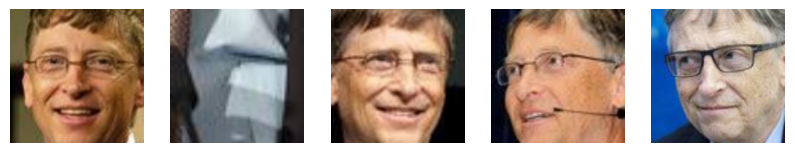

Final face image shape: (160, 160, 3)


In [9]:
import cv2
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces_cropped = []

for img_path, _ in dataset.imgs:
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, (160, 160))
        faces_cropped.append(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
        break

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(faces_cropped[i])
    plt.axis("off")

plt.show()

print("Final face image shape:", faces_cropped[0].shape)

Task 3 - Feature Extraction

In [10]:
import cv2
import numpy as np

X = []
y = []

for i, (img_path, label) in enumerate(dataset.imgs):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y_, w, h) in faces:
        face = gray[y_:y_+h, x:x+w]
        face = cv2.resize(face, (160, 160))
        
        X.append(face)
        y.append(label)
        break

In [11]:
model = cv2.face.LBPHFaceRecognizer_create()

model.train(X, np.array(y))

In [12]:
correct = 0
total = 0

for img_path, label in dataset.imgs:
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y_, w, h) in faces:
        face = gray[y_:y_+h, x:x+w]
        face = cv2.resize(face, (160, 160))

        pred_label, confidence = model.predict(face)

        if pred_label == label:
            correct += 1
        total += 1
        break

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.9980237154150198


In [13]:
model.predict(face)

(4, 0.0)

In [14]:
X_train, y_train = [], []
X_test, y_test = [], []

for i in train_idx:
    img_path, label = dataset.imgs[i]
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y_, w, h) in faces:
        face = gray[y_:y_+h, x:x+w]
        face = cv2.resize(face, (160, 160))
        X_train.append(face)
        y_train.append(label)
        break

for i in test_idx:
    img_path, label = dataset.imgs[i]
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y_, w, h) in faces:
        face = gray[y_:y_+h, x:x+w]
        face = cv2.resize(face, (160, 160))
        X_test.append(face)
        y_test.append(label)
        break

In [15]:
model = cv2.face.LBPHFaceRecognizer_create()
model.train(X_train, np.array(y_train))

Rank-1 Accuracy

In [16]:
correct = 0

for i in range(len(X_test)):
    pred_label, confidence = model.predict(X_test[i])
    
    if pred_label == y_test[i]:
        correct += 1

rank1 = correct / len(X_test)
print("Rank-1 Accuracy:", rank1)

Rank-1 Accuracy: 0.9056603773584906


Rank-3

In [17]:
def compute_distance(img1, img2):
    return np.linalg.norm(img1.flatten() - img2.flatten())

correct_top3 = 0

for i in range(len(X_test)):
    distances = []
    
    for j in range(len(X_train)):
        dist = compute_distance(X_test[i], X_train[j])
        distances.append((dist, y_train[j]))
    
    distances.sort(key=lambda x: x[0])
    
    top3 = [label for _, label in distances[:3]]
    
    if y_test[i] in top3:
        correct_top3 += 1

rank3 = correct_top3 / len(X_test)
print("Rank-3 Accuracy:", rank3)

Rank-3 Accuracy: 0.6509433962264151


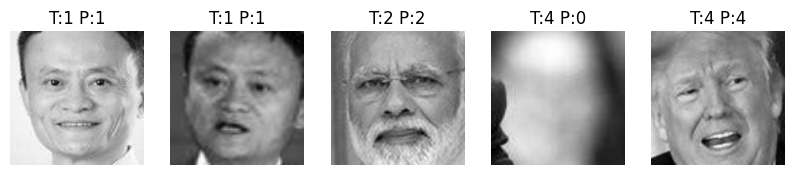

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(5):
    pred_label, _ = model.predict(X_test[i])
    
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"T:{y_test[i]} P:{pred_label}")
    plt.axis("off")

plt.show()

Task 5

In [19]:
def compute_distance(img1, img2):
    return np.linalg.norm(img1.flatten() - img2.flatten())

In [20]:
same_pairs = []
diff_pairs = []

for i in range(len(X_test)):
    for j in range(i+1, len(X_test)):
        if y_test[i] == y_test[j]:
            same_pairs.append((X_test[i], X_test[j]))
        else:
            diff_pairs.append((X_test[i], X_test[j]))

In [21]:
same_pairs = same_pairs[:100]
diff_pairs = diff_pairs[:100]

In [22]:
same_dist = [compute_distance(a, b) for a, b in same_pairs]
diff_dist = [compute_distance(a, b) for a, b in diff_pairs]

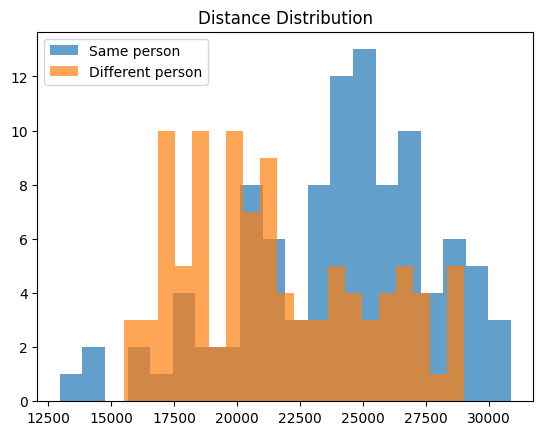

In [23]:
import matplotlib.pyplot as plt

plt.hist(same_dist, bins=20, alpha=0.7, label="Same person")
plt.hist(diff_dist, bins=20, alpha=0.7, label="Different person")
plt.legend()
plt.title("Distance Distribution")
plt.show()

In [24]:
threshold = np.mean(same_dist + diff_dist)
print("Threshold:", threshold)

Threshold: 22766.786607600687


In [ ]:
correct = 0
total = 0

for d in same_dist:
    if d < threshold:
        correct += 1
    total += 1

for d in diff_dist:
    if d >= threshold:
        correct += 1
    total += 1

accuracy = correct / total
print("Verification Accuracy:", accuracy)

Verification Accuracy: 0.325


Task 6

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = []

for i in range(len(X_test)):
    pred_label, _ = model.predict(X_test[i])
    y_pred.append(pred_label)

In [27]:
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9056603773584906
Precision: 0.8954608744082428
Recall: 0.8920383538030597
F1-score: 0.8923767242746153


In [28]:
import pandas as pd

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [acc, precision, recall, f1]
})

print(metrics_table)

      Metric     Value
0   Accuracy  0.905660
1  Precision  0.895461
2     Recall  0.892038
3   F1-score  0.892377


Task 7

In [29]:
import numpy as np

X_train_flat = [img.flatten() for img in X_train]
X_test_flat = [img.flatten() for img in X_test]

X_train_flat = np.array(X_train_flat)
X_test_flat = np.array(X_test_flat)

In [31]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# PCA
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)

y_pred_pca = knn.predict(X_test_pca)

In [32]:
from sklearn.metrics import accuracy_score

acc_pca = accuracy_score(y_test, y_pred_pca)
print("PCA Accuracy:", acc_pca)

PCA Accuracy: 0.6037735849056604


In [33]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": ["LBPH", "PCA"],
    "Accuracy": [acc, acc_pca]
})

print(comparison)

  Method  Accuracy
0   LBPH  0.905660
1    PCA  0.603774


Task 8

In [34]:
errors = []

for i in range(len(X_test)):
    pred_label, _ = model.predict(X_test[i])
    
    if pred_label != y_test[i]:
        errors.append((X_test[i], y_test[i], pred_label))

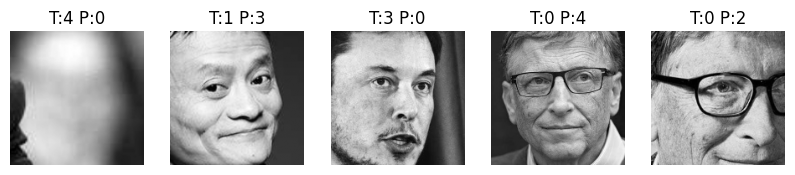

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(min(5, len(errors))):
    img, true_label, pred_label = errors[i]
    
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{true_label} P:{pred_label}")
    plt.axis("off")

plt.show()

Task 9

In [36]:
import time

start = time.time()

for img in X_train:
    _ = img.flatten()

lbph_time = (time.time() - start) / len(X_train)

print("LBPH Feature Extraction Time per image:", lbph_time)

LBPH Feature Extraction Time per image: 6.569623947143555e-06


In [37]:
start = time.time()

for img in X_test:
    model.predict(img)

lbph_pred_time = (time.time() - start) / len(X_test)

print("LBPH Prediction Time per image:", lbph_pred_time)

LBPH Prediction Time per image: 0.005981883912716272


In [38]:
start = time.time()

_ = pca.transform(X_test_flat)

pca_time = (time.time() - start) / len(X_test_flat)

print("PCA Feature Extraction Time per image:", pca_time)

PCA Feature Extraction Time per image: 0.00017542884034930535


In [ ]:
import pandas as pd

efficiency_table = pd.DataFrame({
    "Method": ["LBPH", "PCA"],
    "Feature Extraction Time": [lbph_time, pca_time],
    "Prediction Time": [lbph_pred_time, 0]
})

print(efficiency_table)

  Method  Feature Extraction Time  Prediction Time
0   LBPH                 0.000007         0.005982
1    PCA                 0.000175         0.000000
